# IBM HR Analytics — Exploratory Data Analysis (EDA)

## Objectives
- Load the IBM HR Attrition dataset (prefer cleaned version when available).
- Understand dataset shape, types, and basic summary statistics.
- Check data quality (missing values, duplicates).
- Explore distributions of numeric features (boxplots).
- Explore distributions of categorical features (countplots, limited to low-cardinality columns).

> Note: Advanced statistical screening (normality/Kruskal–Wallis/post-hoc/correlation significance) and dataset-writing steps were removed to keep this notebook focused on EDA and fast to run.

## Notebook walkthrough (Objectives → Conclusion)

> This section explains what each cell in this notebook does, why it exists, and what to look for in the output. It’s written so someone new to the project can follow the analysis end-to-end.

### 1) Import libraries
**Cell: “Importing libraries”**
- Imports `pandas`/`numpy` for data work, and `matplotlib`/`seaborn` for plots.
- This cell should be run first because later cells depend on these imports.

### 2) Load the dataset (robust paths)
**Cell: “Loading the dataset (robust paths)”**
- Uses `pathlib.Path` to try several relative locations for the dataset files.
- Preference order:
  - `data/Cleaned_dataset/IBM_HR_Attrition_cleaned.csv` (if present)
  - otherwise `data/Raw_data/WA_Fn-UseC_-HR-Employee-Attrition.csv`
- Loads the selected CSV into `df` and prints the path actually used.
- The final `df.head()` shows a quick sample to confirm columns look as expected.

### 3) Quick structure + summary statistics
**Cell: `df.info()`**
- Shows the dataset’s shape, column dtypes, and missing-value counts per column.
- Useful for spotting columns that should be numeric/categorical and verifying there are no unexpected nulls.

**Cell: `df.describe()`**
- Displays summary statistics for numeric columns (count/mean/std/min/percentiles/max).
- Helpful for sanity-checking ranges before plotting.

### 4) Data quality checks
**Cell: `df.isna().sum()`**
- Counts missing values per column.
- If you find missingness, you’d decide whether to impute, drop, or encode missingness as a category (depends on use-case).

**Cell: `df.duplicated().sum()`**
- Checks for duplicated rows.
- If duplicates exist, you typically investigate why (data collection vs. true repeats) before dropping.

### 5) Numeric-only view + outlier visualization
**Cell: `df_num = df.select_dtypes(...)`**
- Builds `df_num`, a DataFrame of numeric columns only.
- This is convenient for loops that generate numeric plots or transformations.

**Cell: “Boxplots of Numerical Features”**
- Produces a grid of boxplots—one per numeric feature.
- Boxplots make outliers easy to spot (points beyond whiskers) and show skew/variance.
- This is *visual screening*; it does not change the data.

### 6) Outlier capping on RAW data (winsorization)
The winsorization section intentionally reloads the **raw** CSV into `df_raw` so we can demonstrate cleaning steps transparently, even if `df` was loaded from a pre-cleaned file.

**Cell: “Load RAW dataset explicitly”**
- Loads the raw dataset into `df_raw` and prints its shape.
- The `df_raw.head()` preview confirms we loaded the intended file.

**Cell: “Select numeric features for capping”**
- Creates `df_raw_num` with numeric columns only.
- Drops columns that can’t be winsorized meaningfully:
  - constant columns (no variance),
  - “zero-IQR” columns (IQR = 0), because IQR-based caps become undefined.
- Prints what was kept/dropped.

**Cell: “Winsorization (IQR-based capping)”**
- Uses `feature_engine.outliers.Winsorizer` with:
  - `capping_method='iqr'`, `tail='both'`, `fold=1.5`
- Fits caps and transforms `df_raw` → `df_raw_capped`.
- Builds a `report` showing each variable’s left/right caps and how many values were capped.
- Displays the top capped variables so you can see which features were most affected.

**Cell: “Before vs After Winsorization (Raw Data)”**
- Chooses the top variables with any capping and shows side-by-side boxplots (original vs winsorized).
- The key expectation: extreme points should be pulled back to the cap boundaries, reducing leverage of outliers.

### 7) Categorical distributions
**Cell: “Countplots for categorical features”**
- Selects low-cardinality categorical columns (objects/strings/categories).
- Skips features with too many unique values to keep plots readable.
- Generates countplots to show class balance (useful for EDA and for feature engineering decisions).

### 8) Export + conclusion (added at the end)
- The final cells export a cleaned dataset to `data/Cleaned_dataset/` and summarize key takeaways.

In [1]:
#Importing libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

print ("Libraries imported successfully!")




Libraries imported successfully!


### Explanation (Imports)
This cell imports the core libraries used throughout the notebook:
- `pandas (pd)`: tabular data loading/manipulation (`read_csv`, filtering, summaries).
- `numpy (np)`: numerical utilities (array operations, `ceil`, dtype selection).
- `matplotlib.pyplot (plt)` and `seaborn (sns)`: visualizations (boxplots, countplots).

**Why it matters:** all later cells depend on these imports. If you see `NameError: pd is not defined` or similar, run this cell first.

In [21]:
# Loading the dataset (robust paths)
from pathlib import Path

# Prefer cleaned dataset if present; fall back to raw dataset.
cleaned_name = "IBM_HR_Attrition_cleaned.csv"
raw_name = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

candidate_paths = [
    Path("data/Cleaned_dataset") / cleaned_name,
    Path("../data/Cleaned_dataset") / cleaned_name,
    Path("../../data/Cleaned_dataset") / cleaned_name,
    Path("data/Raw_data") / raw_name,
    Path("../data/Raw_data") / raw_name,
    Path("../../data/Raw_data") / raw_name,
 ]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Could not find the dataset. Tried:\n" + "\n".join(str(p) for p in candidate_paths)
    )

df = pd.read_csv(data_path)
print(f"Loaded dataset from: {data_path}")
df.head()

Loaded dataset from: ../../data/Cleaned_dataset/IBM_HR_Attrition_cleaned.csv


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0.0,8.0,0.0,1,6,4.0,0.0,5.0
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1.0,10.0,3.0,3,10,7.0,1.0,7.0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0.0,7.0,3.0,3,0,0.0,0.0,0.0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0.0,8.0,3.0,3,8,7.0,3.0,0.0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1.0,6.0,3.0,3,2,2.0,2.0,2.0


### Explanation (Dataset loading with robust paths)
This cell tries multiple relative paths to locate the dataset files so the notebook works whether it’s run from the project root or from inside the `jupyter_notebooks/` folder.

**Logic:**
- Prefer the cleaned dataset (`data/Cleaned_dataset/IBM_HR_Attrition_cleaned.csv`) if it exists.
- Otherwise fall back to the raw dataset (`data/Raw_data/WA_Fn-UseC_-HR-Employee-Attrition.csv`).
- The first path that exists becomes `data_path`.
- The selected CSV is read into `df`.
- `df.head()` prints a preview so you can confirm columns and values look sensible.

**What to check in the output:**
- The printed `Loaded dataset from: ...` line should point to the file you expect.
- The preview should show the IBM HR columns (e.g., `Attrition`, `Age`, `MonthlyIncome`, etc.).

**If it errors:**
- A `FileNotFoundError` means the notebook didn’t find either CSV under the expected `data/` structure. Verify the `data/Raw_data/` and `data/Cleaned_dataset/` folders exist and contain the correct filenames.

In [22]:
# Overview of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   str    
 2   BusinessTravel            1470 non-null   str    
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   str    
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   str    
 8   EmployeeCount             1470 non-null   int64  
 9   EmployeeNumber            1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   str    
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel           

### Explanation (`df.info()`)
This cell prints a compact technical summary of the DataFrame `df`:
- Number of rows/columns (dataset shape).
- Column names and data types (e.g., `int64`, `float64`, `object`).
- Non-null counts per column (quick missingness scan).
- Memory usage.

**Why it matters:**
- Helps confirm that numeric fields are recognized as numeric and categoricals as `object`/`string`.
- Flags unexpected missing values early (before plots or modeling).

In [29]:
df.describe()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.764966,11.103061,2.692517,2.761224,6.617687,4.207823,1.922789,4.107483
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.782312,7.303828,1.080497,0.706476,4.989788,3.555335,2.478222,3.517487
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,2.500000,28.500000,4.500000,4.000000,18.000000,14.500000,7.500000,14.500000


### Explanation (`df.describe()`)
This cell generates descriptive statistics for numeric columns in `df`, typically including: count, mean, standard deviation, min, 25%/50%/75% quartiles, and max.

**How to use it:**
- Spot implausible ranges (e.g., negative values where they shouldn’t exist).
- Compare scale differences (helpful before standardization or model selection).
- Identify heavy skew (mean far from median / wide gap between quartiles and max).

In [30]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Explanation (Missing values count)
This cell computes `df.isna().sum()`, which returns the number of missing (`NaN`) values in each column.

**Why it matters:**
- Missingness affects summaries, plots, and especially modeling.
- Even if the dataset is expected to be complete, this quickly confirms that assumption.

**What to do if you find missing values:**
- Decide on an approach: drop rows/columns, impute (mean/median/mode), or use model-based imputation.
- Document the choice so later steps are reproducible.

In [31]:
df.duplicated().sum()


np.int64(0)

### Explanation (Duplicate rows check)
This cell computes `df.duplicated().sum()`, which counts how many rows are exact duplicates of a previous row.

**Interpretation:**
- `0` means there are no perfect duplicate records (good for most use cases).
- A non-zero value suggests repeated entries; you typically investigate before removing them.

**Why it matters:**
- Duplicates can bias distribution plots and model training (they effectively up-weight certain records).

In [32]:
df_num = df.select_dtypes(include=[np.number])
df_num.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,1,2,94,3,2,...,1,80,0.0,8.0,0.0,1,6,4.0,0.0,5.0
1,49,279,8,1,1,2,3,61,2,2,...,4,80,1.0,10.0,3.0,3,10,7.0,1.0,7.0
2,37,1373,2,2,1,4,4,92,2,1,...,2,80,0.0,7.0,3.0,3,0,0.0,0.0,0.0
3,33,1392,3,4,1,5,4,56,3,1,...,3,80,0.0,8.0,3.0,3,8,7.0,3.0,0.0
4,27,591,2,1,1,7,1,40,3,1,...,4,80,1.0,6.0,3.0,3,2,2.0,2.0,2.0


### Explanation (Numeric subset `df_num`)
This cell creates `df_num` by selecting only numeric columns from `df` using `select_dtypes(include=[np.number])`.

**Why we do this:**
- Many EDA tasks (like boxplots and outlier checks) apply only to numeric variables.
- Keeping a numeric-only DataFrame makes it easy to loop over columns without handling categoricals.

**Output to expect:**
- `df_num.head()` shows the first few rows of numeric columns only.

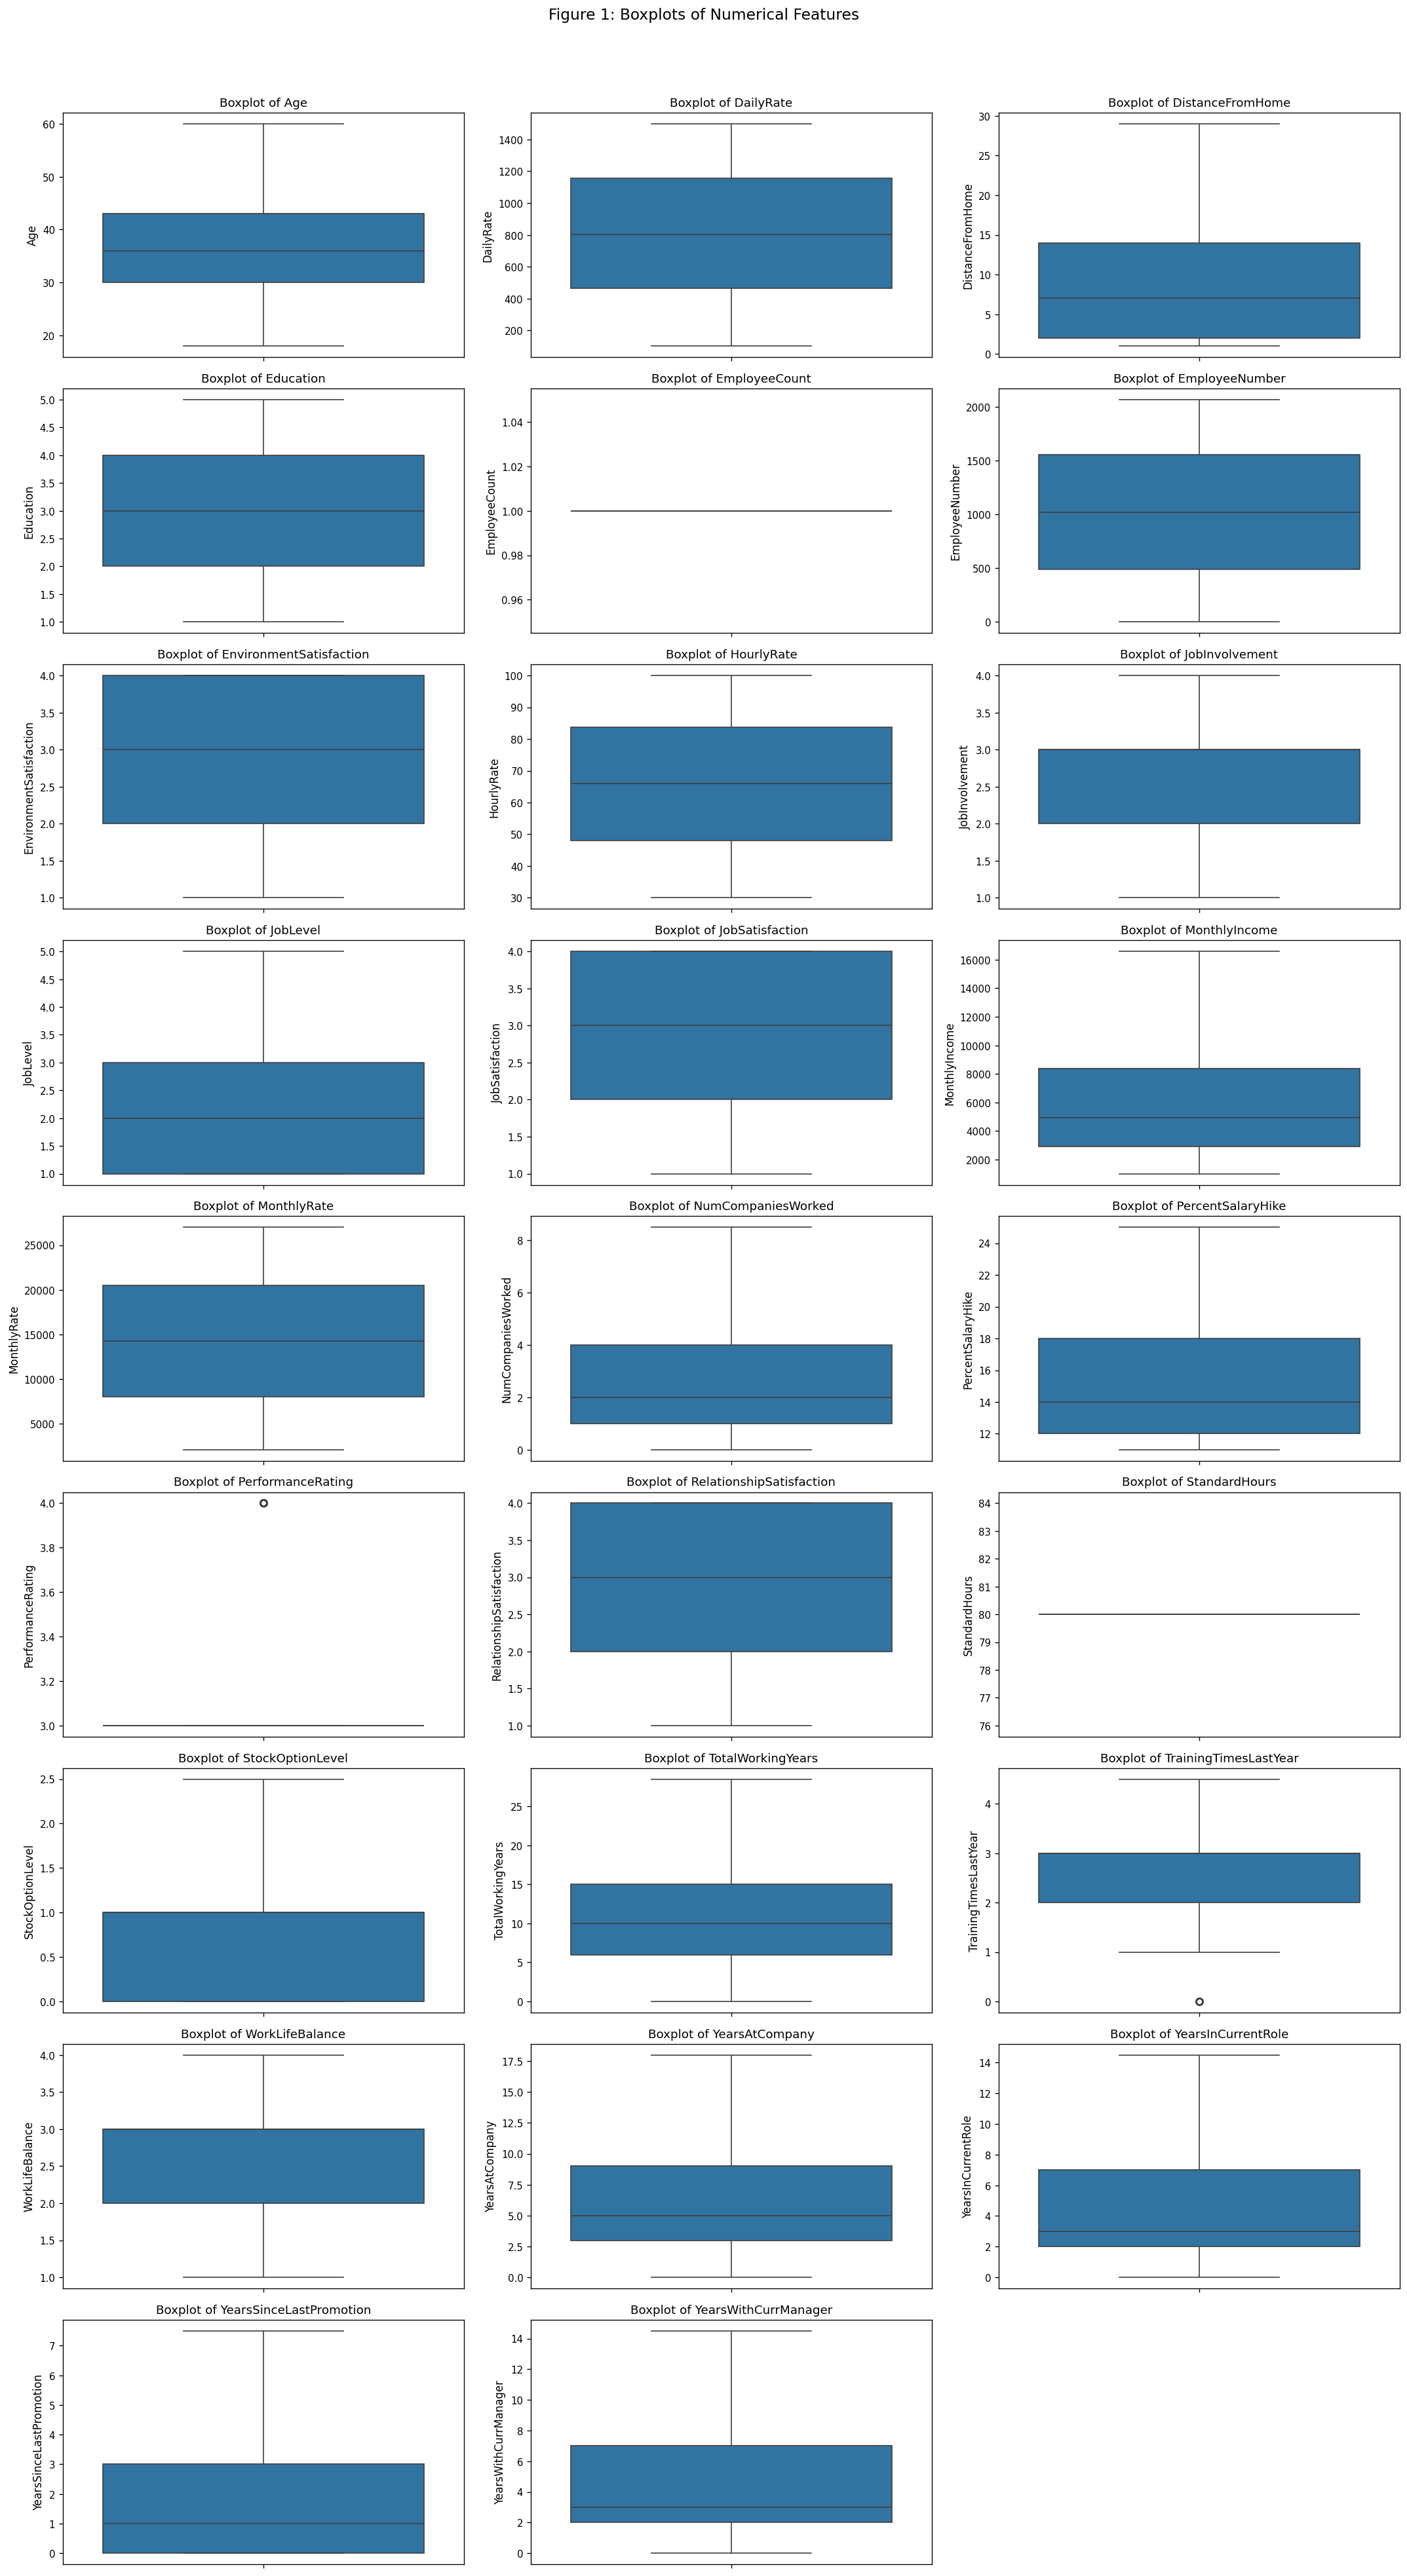

In [33]:
# Using boxplot to observe outliers in the numerical features

n_features = df_num.shape[1]
if n_features == 0:
    print("No numeric columns found in df_num.")
else:
    # Make subplots bigger/readable
    n_cols = 3
    subplot_width = 6
    subplot_height = 3.6
    dpi = 120

    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(subplot_width * n_cols, subplot_height * n_rows),
        dpi=dpi,
    )
    axes = np.array(axes).reshape(-1)

    for ax, column in zip(axes, df_num.columns):
        sns.boxplot(y=df_num[column], ax=ax)
        ax.set_title(f"Boxplot of {column}", fontsize=11)
        ax.tick_params(axis="both", labelsize=9)

    # Hide any unused subplots
    for ax in axes[len(df_num.columns) :]:
        ax.axis("off")

    fig.suptitle("Figure 1: Boxplots of Numerical Features", y=1.01, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()

### Explanation (Boxplots for numeric outliers)
This cell generates a grid of Seaborn boxplots—one boxplot per numeric feature in `df_num`.

**What the boxplot shows:**
- The **box** spans the interquartile range (IQR: 25th to 75th percentile).
- The **line** inside the box is the median (50th percentile).
- The **whiskers** extend to typical ranges (often up to 1.5×IQR).
- Points beyond the whiskers are plotted as **potential outliers**.

**Why it matters:**
- Quickly highlights variables with strong skew or extreme values (e.g., income, tenure-related measures).
- Helps decide whether outlier treatment (like winsorization) is appropriate.

**Note:** this is a visualization step only; it does not modify the dataset.

# Outlier capping on the **raw** data (Winsorization)

The boxplots above help us *see* potential outliers, but for modeling we often want a **robust, repeatable transformation** that reduces the effect of extreme values without deleting rows.

## What is winsorization?
**Winsorization** caps extreme values to a chosen boundary so that values above an upper cap are replaced by the cap (and similarly for lower outliers).

Common choices for caps:
- **IQR rule**: $[Q1 - k·IQR, Q3 + k·IQR]$ (often $k=1.5$).
- **Quantile capping**: e.g., cap below the 1st percentile and above the 99th percentile.

We will use `feature_engine.outliers.Winsorizer` so the capping thresholds are learned during `fit()` and then applied consistently during `transform()`.

## Important modeling note (data leakage)
For a real ML pipeline, **fit the winsorizer on the training set only** and then transform both train and test. In this EDA section we fit on the full raw dataset for demonstration.

## Goal of this section
- Load the **raw** CSV (even if the notebook earlier loaded the cleaned version).
- Apply winsorization to numeric columns.
- Show a compact report of which features were capped and by how much.
- Visualize before/after boxplots for the most-affected variables.

In [2]:
# Load RAW dataset explicitly (for winsorization demo)
from pathlib import Path

raw_name = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
raw_candidate_paths = [
    Path("data/Raw_data") / raw_name,
    Path("../data/Raw_data") / raw_name,
    Path("../../data/Raw_data") / raw_name,
]

raw_path = next((p for p in raw_candidate_paths if p.exists()), None)
if raw_path is None:
    raise FileNotFoundError(
        "Could not find RAW dataset. Tried:\n" + "\n".join(str(p) for p in raw_candidate_paths)
    )

df_raw = pd.read_csv(raw_path)
print(f"Loaded RAW dataset from: {raw_path}")
print("Shape:", df_raw.shape)
df_raw.head()

Loaded RAW dataset from: ../../data/Raw_data/WA_Fn-UseC_-HR-Employee-Attrition.csv
Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Explanation (Load raw dataset for cleaning demo)
This cell loads the **raw** IBM HR dataset into `df_raw` (separately from `df`).

**Why load raw again?**
- The notebook may already be using a cleaned file for general EDA (`df`).
- For outlier capping, we want a transparent demonstration of the transformation starting from the raw source.

**What to check:**
- The printed path confirms which file was loaded.
- The shape should match the known raw dataset size (commonly 1470 rows for this IBM HR dataset).
- `df_raw.head()` should show the same column set as the raw CSV.

In [6]:
# Select numeric features for capping (exclude zero-variance columns)
df_raw_num = df_raw.select_dtypes(include=[np.number]).copy()

if df_raw_num.shape[1] == 0:
    print("No numeric columns found in raw data.")
else:
    # Drop constant numeric columns (winsorization not meaningful there)
    nunique = df_raw_num.nunique(dropna=False)
    constant_cols = nunique[nunique <= 1].index.tolist()
    df_raw_num = df_raw_num.drop(columns=constant_cols, errors="ignore")

    # Drop very low-variation columns for IQR capping (IQR == 0 makes caps undefined)
    q1 = df_raw_num.quantile(0.25)
    q3 = df_raw_num.quantile(0.75)
    iqr = q3 - q1
    zero_iqr_cols = iqr[iqr <= 0].index.tolist()
    df_raw_num = df_raw_num.drop(columns=zero_iqr_cols, errors="ignore")

    num_vars = df_raw_num.columns.tolist()
    print(f"Numeric variables considered for winsorization: {len(num_vars)}")
    if constant_cols:
        print(f"Dropped constant numeric columns: {constant_cols}")
    if zero_iqr_cols:
        print(f"Dropped zero-IQR (low-variation) numeric columns: {zero_iqr_cols}")
    num_vars[:15]  # preview

Numeric variables considered for winsorization: 23
Dropped constant numeric columns: ['EmployeeCount', 'StandardHours']
Dropped zero-IQR (low-variation) numeric columns: ['PerformanceRating']


### Explanation (Choose numeric variables for winsorization)
This cell prepares the list of numeric variables that are safe and meaningful to winsorize.

**Steps performed:**
1. `df_raw.select_dtypes(include=[np.number])` selects numeric columns only.
2. Drops **constant** numeric columns (only one unique value). These don’t carry information and can cause issues in some transformations.
3. Drops **zero-IQR** numeric columns. For IQR-based caps, if IQR = 0 then the cap boundaries collapse and `feature_engine` will raise an error.

**Outputs:**
- A message showing how many numeric variables will be winsorized.
- Lists of dropped columns (if any), so the transformation is fully transparent and reproducible.

In [9]:
# Winsorization (IQR-based capping)
from feature_engine.outliers import Winsorizer
from IPython.display import display

if df_raw_num.shape[1] == 0:
    df_raw_capped = df_raw.copy()
    report = pd.DataFrame()
    print("Skipped winsorization: no numeric variables found.")
else:
    win = Winsorizer(
        capping_method="iqr",  # IQR rule
        tail="both",          # cap both tails
        fold=1.5,               # k in the IQR rule
        variables=df_raw_num.columns.tolist(),
    )

    # Fit on raw numeric data and transform
    win.fit(df_raw)
    df_raw_capped = win.transform(df_raw)

    # Build a capping report
    left_caps = getattr(win, "left_tail_caps_", {})
    right_caps = getattr(win, "right_tail_caps_", {})

    changed_mask = (df_raw[df_raw_num.columns] != df_raw_capped[df_raw_num.columns])
    n_changed = changed_mask.sum().sort_values(ascending=False)
    pct_changed = (n_changed / len(df_raw) * 100).round(3)

    report = pd.DataFrame({
        "left_cap": pd.Series(left_caps, dtype="float64"),
        "right_cap": pd.Series(right_caps, dtype="float64"),
    }).reindex(df_raw_num.columns)

    report["n_capped"] = n_changed.reindex(report.index).fillna(0).astype(int)
    report["pct_capped"] = pct_changed.reindex(report.index).fillna(0.0)
    report = report.sort_values("n_capped", ascending=False)

    print("Top variables by number of capped values:")
    display(report.head(12))

Top variables by number of capped values:


,left_cap,right_cap,n_capped,pct_capped
TrainingTimesLastYear,0.5,4.5,238,16.190
MonthlyIncome,-5291.0,16581.0,114,7.755
YearsSinceLastPromotion,-4.5,7.5,107,7.279
YearsAtCompany,-6.0,18.0,104,7.075
StockOptionLevel,-1.5,2.5,85,5.782
TotalWorkingYears,-7.5,28.5,63,4.286
NumCompaniesWorked,-3.5,8.5,52,3.537
YearsInCurrentRole,-5.5,14.5,21,1.429
YearsWithCurrManager,-5.5,14.5,14,0.952
WorkLifeBalance,0.5,4.5,0,0.000


### Explanation (Apply Winsorizer + build capping report)
This cell applies **IQR-based winsorization** using `feature_engine.outliers.Winsorizer`.

**Configuration used:**
- `capping_method='iqr'`: compute caps using the IQR rule.
- `tail='both'`: cap both lower and upper tails.
- `fold=1.5`: use the common 1.5×IQR threshold.
- `variables=[...]`: apply only to the numeric variables selected in the previous step.

**What happens in `fit()` and `transform()`:**
- `fit(df_raw)` learns the lower/upper cap values per variable.
- `transform(df_raw)` returns `df_raw_capped`, where values outside the caps are replaced by the cap boundary.

**The `report` table:**
- `left_cap` / `right_cap`: the learned capping thresholds per variable.
- `n_capped`: how many rows were changed (capped) for that variable.
- `pct_capped`: the percent of rows capped for that variable.

**How to interpret it:**
- If a variable has `n_capped = 0`, winsorization didn’t change that feature.
- The variables at the top of the table are the ones most affected by outlier capping (often the best candidates to visualize next).

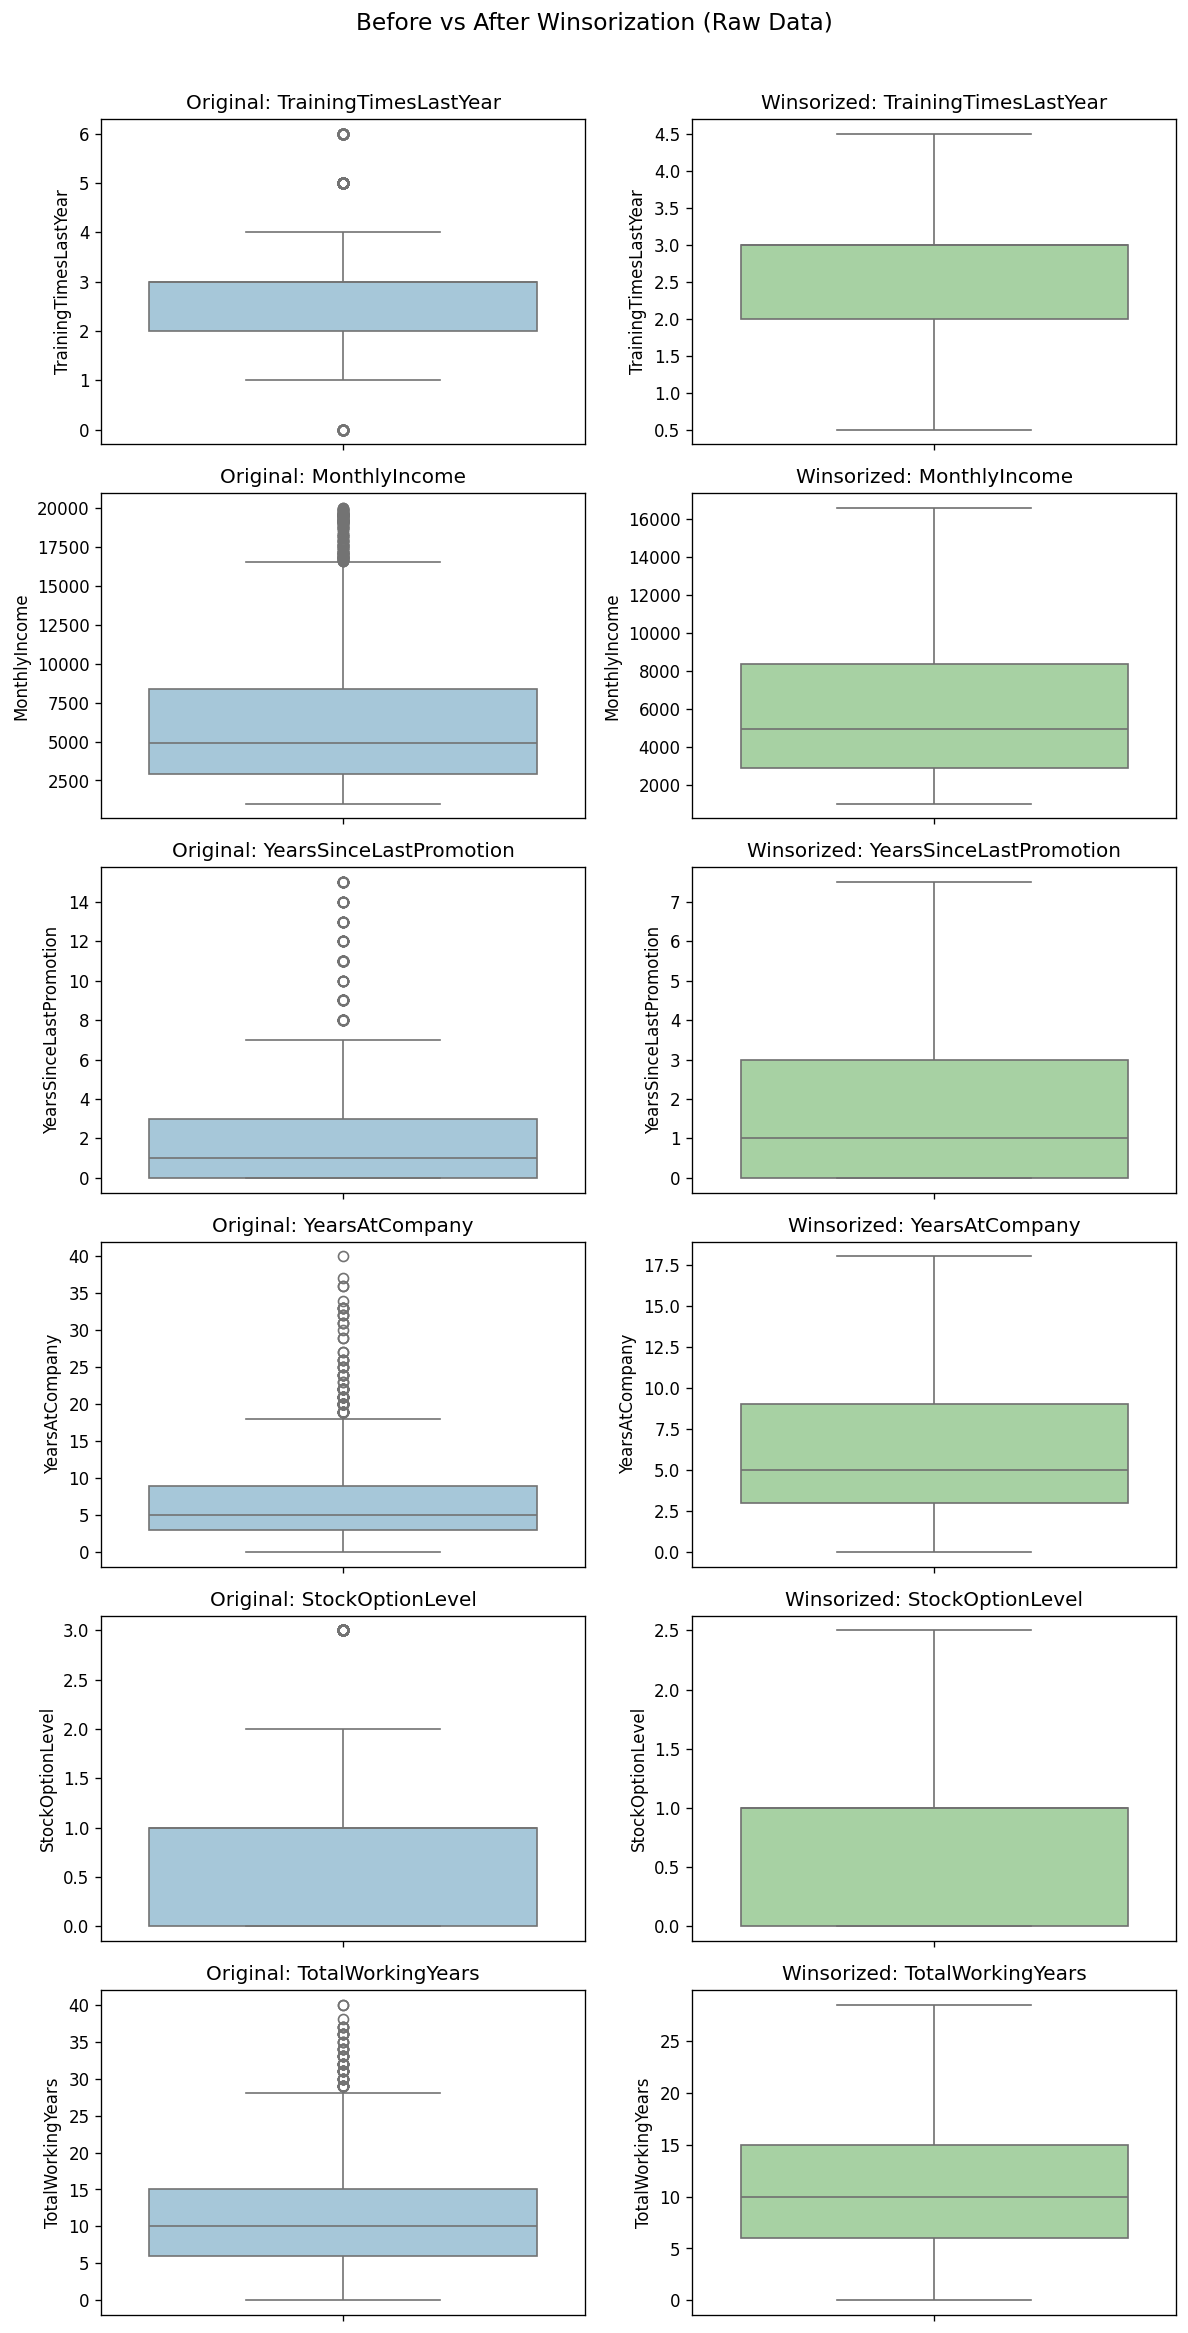

In [10]:
# Before/After boxplots for the most affected variables
if df_raw_num.shape[1] == 0:
    print("No plots: no numeric variables found.")
else:
    top_vars = report.index[report["n_capped"] > 0].tolist()[:6]
    if not top_vars:
        print("No values were capped with the current settings (IQR, fold=1.5).")
    else:
        n = len(top_vars)
        fig, axes = plt.subplots(n, 2, figsize=(10, 3.2 * n), dpi=120)
        if n == 1:
            axes = np.array([axes])

        for i, var in enumerate(top_vars):
            sns.boxplot(y=df_raw[var], ax=axes[i, 0], color="#9ecae1")
            axes[i, 0].set_title(f"Original: {var}")
            sns.boxplot(y=df_raw_capped[var], ax=axes[i, 1], color="#a1d99b")
            axes[i, 1].set_title(f"Winsorized: {var}")

        fig.suptitle("Before vs After Winsorization (Raw Data)", y=1.01, fontsize=14)
        fig.tight_layout()
        plt.show()

### Explanation (Before vs after plots for winsorization)
This cell selects the top variables that had any capped values (`n_capped > 0`) and plots **side-by-side boxplots**:
- Left: the original raw variable (`df_raw[var]`).
- Right: the winsorized version (`df_raw_capped[var]`).

**What you should see:**
- Extreme points (outliers) in the original plot should be pulled back to the whisker/cap boundary in the winsorized plot.
- The median and IQR usually remain similar, but the maximum/minimum become less extreme.

**If you see the message “No values were capped…”**
- It means that, under the IQR rule with `fold=1.5`, no observations fell outside the caps for any variable. In that case, you might try a smaller fold or quantile-based capping.

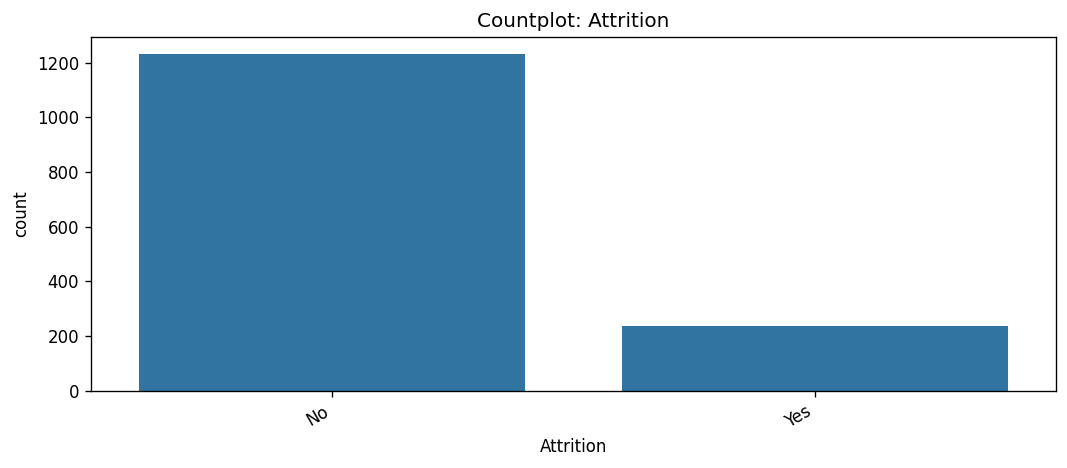

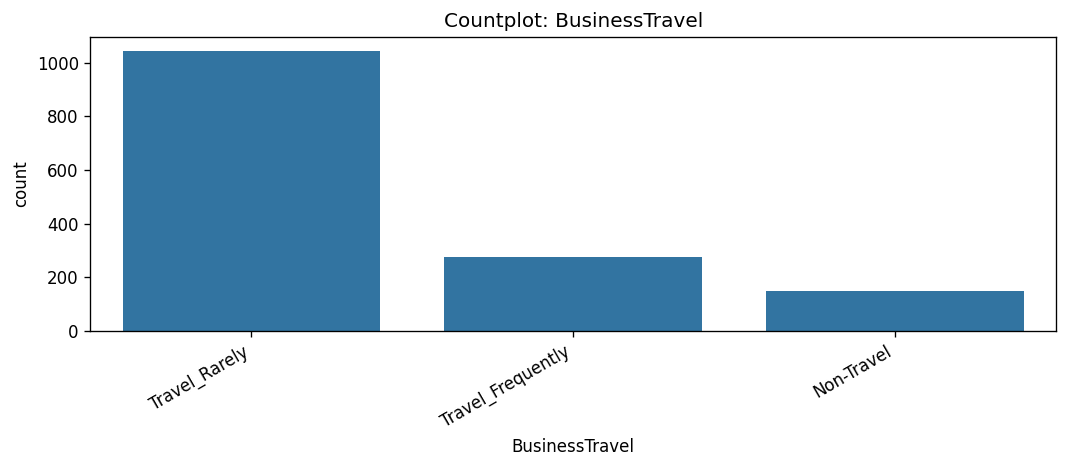

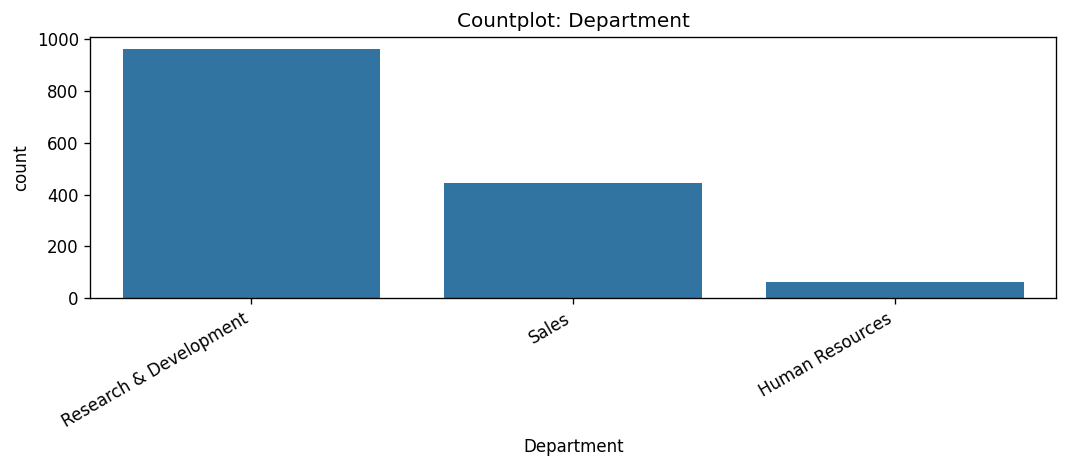

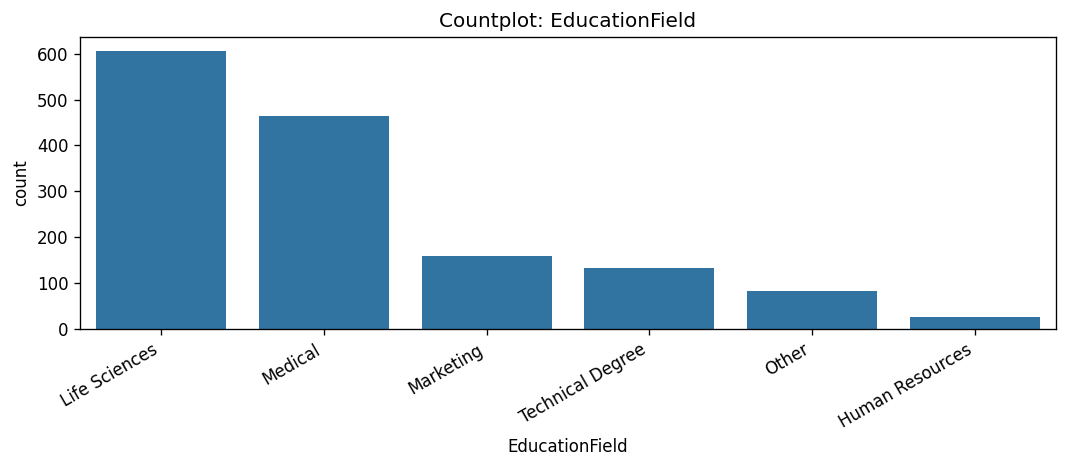

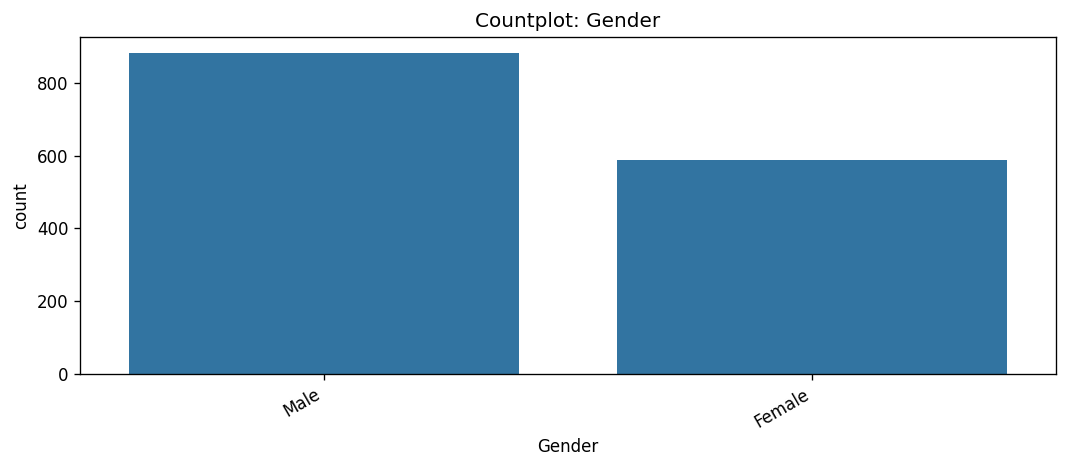

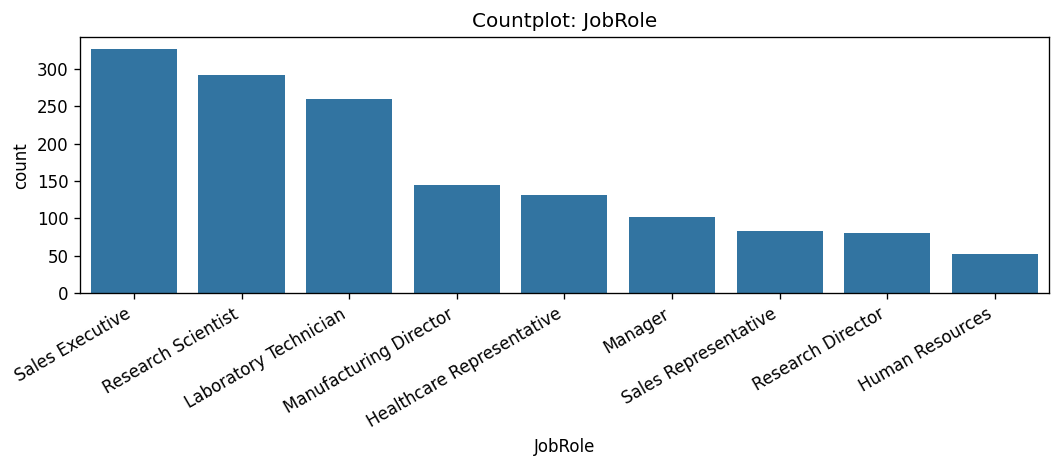

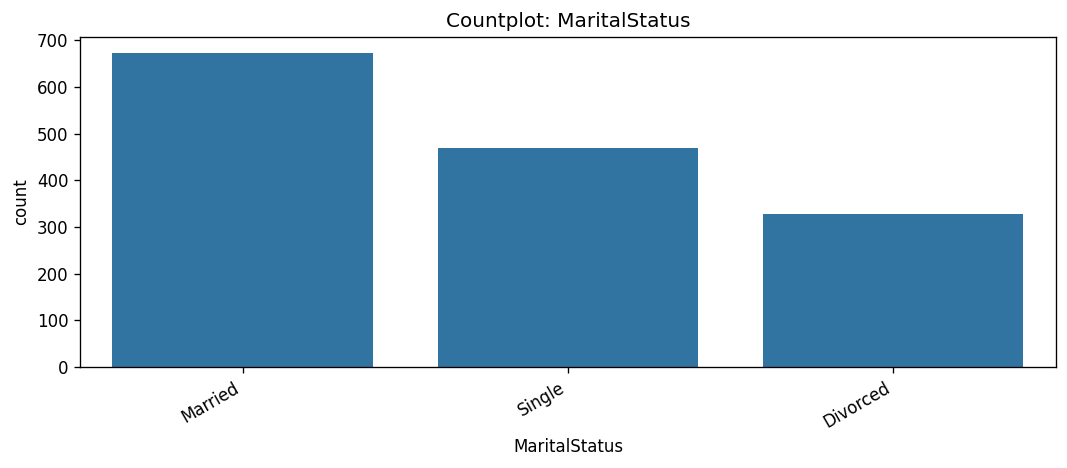

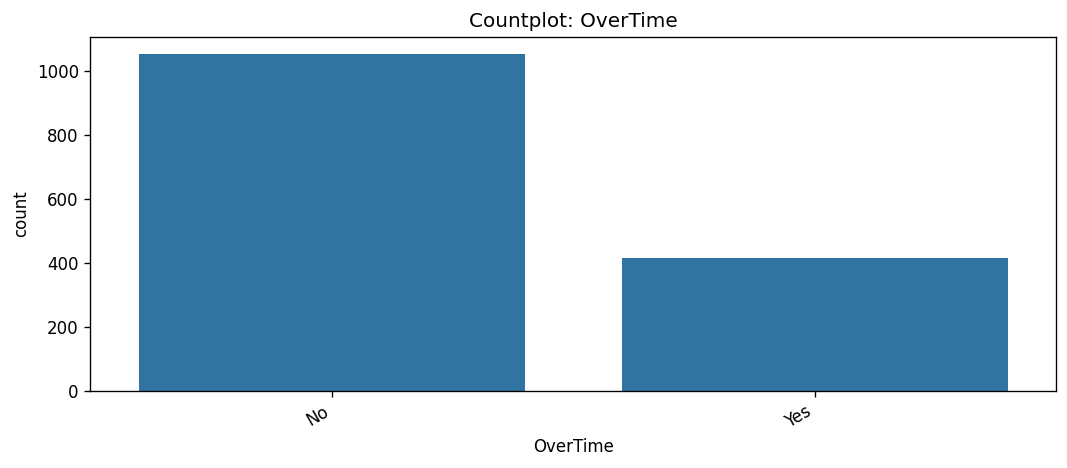

In [34]:
# Countplots for categorical features (low-cardinality only)

# Pandas 3.x note: include both object + string dtypes to avoid deprecation warnings.
cat_cols = df.select_dtypes(include=["object", "category", "string"]).columns

max_unique = 15  # skip very high-cardinality categoricals

for col in cat_cols:
    n_unique = df[col].nunique(dropna=True)
    if n_unique < 2 or n_unique > max_unique:
        continue

    order = df[col].value_counts(dropna=False).index
    plt.figure(figsize=(9, 4), dpi=120)
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Countplot: {col}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

### Explanation (Categorical countplots)
This cell explores **categorical** columns by plotting value counts (countplots) for low-cardinality features.

**What it does:**
- Selects columns with dtype `object`, `category`, or `string`.
- Skips columns with too many unique values (`max_unique = 15`) to keep charts readable.
- For each remaining column, it plots the frequency of each category.

**How to interpret:**
- Look for strong imbalance (one category dominating), which may matter for modeling and for fair comparisons.
- Identify rare categories that might need grouping ("Other") or careful encoding.

**Why the uniqueness filter matters:**
- High-cardinality categories (e.g., an ID-like column) produce unreadable plots and usually require different treatment (target encoding, hashing, grouping, etc.).

In [ ]:
# Save a cleaned dataset to data/Cleaned_dataset/
#
# This notebook may load an already-cleaned dataset into `df`.
# In the winsorization section, we create `df_raw_capped` as a cleaned version of the raw data.
# Here we save the best available cleaned dataset for reuse in modeling notebooks/pipelines.

from pathlib import Path

# Prefer the winsorized-raw output if it exists; otherwise fall back to `df`.
if "df_raw_capped" in globals():
    df_to_save = df_raw_capped.copy()
    source_label = "df_raw_capped (winsorized raw)"
elif "df" in globals():
    df_to_save = df.copy()
    source_label = "df (loaded dataset)"
else:
    raise NameError("No dataset found to save. Run the data loading cells first.")

output_name = "IBM_HR_Attrition_cleaned.csv"
out_dir_candidates = [
    Path("data/Cleaned_dataset"),
    Path("../data/Cleaned_dataset"),
    Path("../../data/Cleaned_dataset"),
    Path("data/Cleaned_dataset"),  # fallback create here if none exists
 ]
out_dir = next((p for p in out_dir_candidates if p.exists()), out_dir_candidates[0])
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / output_name
df_to_save.to_csv(out_path, index=False)

print(f"Saved cleaned dataset from {source_label} to: {out_path.resolve()}")
print("Shape:", df_to_save.shape)

### Explanation (Export cleaned dataset)
This cell writes a reusable **cleaned dataset** into the `data/Cleaned_dataset/` folder.

**What it saves:**
- If the winsorization section was run, `df_raw_capped` exists and is treated as the cleaned output (raw data after outlier capping).
- Otherwise it falls back to `df` (whatever dataset was loaded earlier: cleaned or raw).

**File written:**
- `IBM_HR_Attrition_cleaned.csv`

**Why this is helpful:**
- Downstream notebooks (feature engineering, modeling) can load a single consistent cleaned file.
- Keeps the raw file unchanged while allowing iterative improvements to the cleaned version.

**Note on overwriting:**
- Re-running this cell overwrites the existing cleaned CSV with the latest `df_raw_capped`/`df` content. If you want versioning, we can add a timestamped filename.

## Conclusion

**What we did**
- Loaded the IBM HR Attrition dataset and performed quick structural checks (`info`, `describe`).
- Verified data quality basics (missing values and duplicates).
- Visually screened numeric variables for outliers via boxplots.
- Demonstrated a robust outlier-treatment approach on the **raw** dataset using IQR-based winsorization.
- Reviewed categorical distributions via countplots for low-cardinality features.

**Key takeaway**
- Winsorization reduces the influence of extreme values while preserving all rows, which can make downstream models more stable.

**Next steps (optional)**
- Fit winsorization on the training split only (to avoid leakage) and package it into a scikit-learn pipeline.
- Compare IQR-based vs quantile-based capping (1%/99%) for sensitive features like income-related variables.
- Proceed to feature encoding and baseline modeling (e.g., logistic regression / tree-based models).